In [2]:
import sys
import os as os

import geopandas as gpd
import numpy as np
from numpy.polynomial import Polynomial
import psycopg2
from netCDF4 import Dataset

from tqdm import tqdm
from multiprocessing import Pool
import statsmodels.api as sm
from scipy import stats
# from scipy import optimize

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature as cfNEF

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
#import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D

import rasterio
import xarray as xr

import random
import subprocess
import netCDF4
import shutil

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
import seaborn as sns
from scipy.stats import gaussian_kde

import pathlib
import glob
import pandas as pd

from sklearn.metrics import r2_score

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import requests
import io

# Overview

### This Code looks at time series data for snow gauges where IDW interpolation method performed the worst. Each assimilation date was examined to find any reasons why the performance at these gauges were not very accurate.

# 12/28/23 Assimilation Gauge Time Series Data for Worst Performing Stations

## Upload guage data and IDW results to find top 10 worst performing 

Upload LOO-CV results from IDW Method and Find Worst Performing Gauges

In [3]:
# Create a list of all UMRB Station names so you can remove from assimilation

# Read the CSV file
UMRB_ID = pd.read_csv(r'C:\Repos\umrb-snodas\resources\Current_UMRB_Station_List.csv')

# Create station ID List
UMRB_ID = UMRB_ID['station_id'].to_list()

Load LOO-CV results file

In [11]:
# Load the CSV file into a DataFrame
df = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\cross_val_12_28_23_updated')

# Drop the first column by index (0)
df = df.drop(df.columns[0], axis=1)

# Calculate the difference between observed and analysis values
df['difference'] = df['observed'] - df['analysis']

# Make a list of just UMRB Stations
UMRB_df = df[df['site_ids'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df = df[~df['site_ids'].isin(UMRB_ID)]

df = df.rename(columns={'site_ids': 'STATION_ID'})

df

,observed,analysis,STATION_ID,difference
0,20.94453,19.846887,8D3,1.097643
1,21.12781,20.550749,ABES2,0.577061
2,21.12781,20.546585,ABR,0.581225
3,-8.85243,-8.379408,ADAM054,-0.473022
4,15.76905,4.219715,ADAN1,11.549335
...,...,...,...,...
956,-3.20040,-2.258211,WNGN8,-0.942189
957,2.16424,10.157488,WNMS2,-7.993248
958,-10.74352,-3.603530,WRIS2,-7.139990
959,8.79091,8.260490,WTES2,0.530420


Load file showing staion data for all stations used in Analysis in order to add attributes to LOO-CV dataframe

In [12]:
# Read the CSV file
df_2 = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\snow_gauges_event_threshold_atrribute_table.csv')

df_2

,VALUE,POINTID,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,TRUE_FLAG,...,D_NSP_OM,OB_NSN_P,MD_NSN_P,URL,layer,path,POINT_X,POINT_Y,X,Y
0,0.0,0,45.670800,-96.996100,8D3,ASOS,353.0,350.0,5.0,-1.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-96.99610,45.67080,-96.99610,45.67080
1,0.0,0,45.455300,-98.414100,ABES2,COOPABC,395.0,395.0,4.0,-1.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.41410,45.45530,-98.41410,45.45530
2,0.0,0,45.455800,-98.412800,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,-1.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.41280,45.45580,-98.41280,45.45580
3,0.0,0,40.594882,-98.426962,ADAM054,NERAIN,595.0,594.0,4.0,-1.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.42696,40.59488,-98.42696,40.59488
4,0.0,0,40.452000,-96.510600,ADAN1,COOPBC,405.0,397.0,8.0,-1.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-96.51060,40.45200,-96.51060,40.45200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,0.0,0,47.271900,-100.330300,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,-1.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-100.33030,47.27190,-100.33030,47.27190
957,0.0,0,43.310000,-99.690000,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,-1.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-99.69000,43.31000,-99.69000,43.31000
958,0.0,0,43.560000,-100.740000,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,-1.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-100.74000,43.56000,-100.74000,43.56000
959,0.0,0,43.732200,-98.693900,WTES2,UMRB,-9999.0,-9999.0,-9999.0,-1.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.69390,43.73220,-98.69390,43.73220


Merge dataframes into one dataframe in order to have all gauge attributes in one dataframe

In [13]:
# Perform the join based on the STATION_ID column
merged_df = pd.merge(df, df_2, on='STATION_ID')

merged_df

,observed,analysis,STATION_ID,difference,VALUE,POINTID,LATITUDE,LONGITUDE,STATION_TY,STATION_EL,...,D_NSP_OM,OB_NSN_P,MD_NSN_P,URL,layer,path,POINT_X,POINT_Y,X,Y
0,20.94453,19.846887,8D3,1.097643,0.0,0,45.670800,-96.996100,ASOS,353.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-96.99610,45.67080,-96.99610,45.67080
1,21.12781,20.550749,ABES2,0.577061,0.0,0,45.455300,-98.414100,COOPABC,395.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.41410,45.45530,-98.41410,45.45530
2,21.12781,20.546585,ABR,0.581225,0.0,0,45.455800,-98.412800,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.41280,45.45580,-98.41280,45.45580
3,-8.85243,-8.379408,ADAM054,-0.473022,0.0,0,40.594882,-98.426962,NERAIN,595.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.42696,40.59488,-98.42696,40.59488
4,15.76905,4.219715,ADAN1,11.549335,0.0,0,40.452000,-96.510600,COOPBC,405.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-96.51060,40.45200,-96.51060,40.45200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,-3.20040,-2.258211,WNGN8,-0.942189,0.0,0,47.271900,-100.330300,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-100.33030,47.27190,-100.33030,47.27190
961,2.16424,10.157488,WNMS2,-7.993248,0.0,0,43.310000,-99.690000,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-99.69000,43.31000,-99.69000,43.31000
962,-10.74352,-3.603530,WRIS2,-7.139990,0.0,0,43.560000,-100.740000,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-100.74000,43.56000,-100.74000,43.56000
963,8.79091,8.260490,WTES2,0.530420,0.0,0,43.732200,-98.693900,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.69390,43.73220,-98.69390,43.73220


IMPORTANT!!! I found guages used multiple times in assimlation because the 12/29/23 date snow measurements were used along with the 12/28/23 snow measurements. The 12/29/23 measurements were removed below in order to not keep duplicates

In [ ]:
# Filter out rows where MD_SWE_T is '2023/12/29 12'
df_filtered = merged_df[merged_df['MD_SWE_T'] != '2023/12/29 12']

# Drop duplicates in STATION_ID, keeping only the first occurrence
df_unique = df_filtered.drop_duplicates(subset='STATION_ID')

df_unique

Find top 10 worst performing gauges

In [87]:
# Get the top 10 rows with the highest absolute values in the 'difference' column
top_10_abs_difference = merged_df.loc[merged_df['difference'].abs().nlargest(10).index]

# Display the result
top_10_abs_difference

,observed,analysis,STATION_ID,difference,VALUE,POINTID,LATITUDE,LONGITUDE,STATION_TY,STATION_EL,...,D_NSP_OM,OB_NSN_P,MD_NSN_P,URL,layer,path,POINT_X,POINT_Y,X,Y
936,-36.414630,11.471155,MARN8,-47.885785,0.0,0,46.564500,-98.327600,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.32760,46.56450,-98.32760,46.56450
955,-16.015210,20.409693,TIMS2,-36.424903,0.0,0,45.416800,-101.084100,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-101.08410,45.41680,-101.08410,45.41680
789,24.890640,-11.233986,TLKS2,36.124626,0.0,0,45.428400,-101.076400,COOPAB,666.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-101.07640,45.42840,-101.07640,45.42840
923,-19.951550,15.990926,GOTS2,-35.942476,0.0,0,45.573500,-98.030100,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.03010,45.57350,-98.03010,45.57350
917,-29.297904,3.656937,CURN8,-32.954841,0.0,0,47.221000,-98.680000,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.68000,47.22100,-98.68000,47.22100
944,32.837490,2.160983,OCMS2,30.676507,0.0,0,43.793900,-99.412700,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-99.41270,43.79390,-99.41270,43.79390
733,-32.362960,-2.908361,SD-ML-3,-29.454599,0.0,0,43.448433,-101.217484,COCORAHS,785.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-101.21748,43.44843,-101.21748,43.44843
113,-26.933320,0.508607,CO-KC-80,-27.441927,0.0,0,39.416600,-102.203600,COCORAHS,1233.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-102.20360,39.41660,-102.20360,39.41660
933,-14.076560,12.651420,LCMS2,-26.727980,0.0,0,43.900000,-98.110000,UMRB,-9999.0,...,99999.0,99999.0,99999.0,,umrb_deltas_20231228_CORRECT_p1_formatted,/Users/carrie.olheiser/Documents/UMRB_project/...,-98.11000,43.90000,-98.11000,43.90000
811,-25.400000,0.505982,WACI4,-25.905982,0.0,0,43.060300,-92.048900,COOPB,344.0,...,99999.0,99999.0,99999.0,https://www.nohrsc.noaa.gov/interactive/html/g...,ssm1054_md_based_2023122712_2023122812_east_CO...,/Users/carrie.olheiser/Documents/UMRB_project/...,-92.04890,43.06030,-92.04890,43.06030


Find closest station to each of the worst performing UMRB stations

In [ ]:
# Filter top_10_abs_difference for UMRB stations
umrb_stations = top_10_abs_difference[top_10_abs_difference['STATION_TY'] == 'UMRB']

# Define the Haversine distance function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Create a list to store the results
closest_stations = []

# Loop through each UMRB station
for index, umrb_row in umrb_stations.iterrows():
    umrb_lat, umrb_lon = umrb_row['LATITUDE'], umrb_row['LONGITUDE']
    umrb_station_id = umrb_row['STATION_ID']
    
    # Exclude the UMRB station itself from df_unique
    df_filtered = df_unique[df_unique['STATION_ID'] != umrb_station_id]

    # Calculate the Haversine distance from the UMRB station to all stations in df_filtered
    df_filtered['distance'] = df_filtered.apply(
        lambda x: haversine(umrb_lat, umrb_lon, x['LATITUDE'], x['LONGITUDE']), axis=1
    )
    
    # Find the closest station from the filtered DataFrame
    closest_station = df_filtered.loc[df_filtered['distance'].idxmin()]
    
    # Store the result
    closest_stations.append({
        'UMRB_Station_ID': umrb_station_id,
        'UMRB_Latitude': umrb_lat,
        'UMRB_Longitude': umrb_lon,
        'Closest_Station_ID': closest_station['STATION_ID'],
        'Closest_Latitude': closest_station['LATITUDE'],
        'Closest_Longitude': closest_station['LONGITUDE'],
        'Distance_km': closest_station['distance']
    })

# Create a DataFrame from the results
closest_stations_df = pd.DataFrame(closest_stations)

# Display the result
print(closest_stations_df)



  UMRB_Station_ID  UMRB_Latitude  UMRB_Longitude Closest_Station_ID  \
0           MARN8        46.5645        -98.3276              LMRN8   
1           TIMS2        45.4168       -101.0841              TLKS2   
2           GOTS2        45.5735        -98.0301              ANVS2   
3           CURN8        47.2210        -98.6800              JSTN8   
4           OCMS2        43.7939        -99.4127           SD-BL-10   
5           LCMS2        43.9000        -98.1100                MHE   

   Closest_Latitude  Closest_Longitude  Distance_km  
0          46.36670           -98.2833    22.254520  
1          45.42840          -101.0764     1.422981  
2          45.41330           -97.9067    20.244402  
3          46.90640           -98.9274    39.684835  
4          43.70514           -99.3773    10.271100  
5          43.77470           -98.0383    15.072890  


C:\Users\clemasters\AppData\Local\Temp\ipykernel_20816\1446039819.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['distance'] = df_filtered.apply(
C:\Users\clemasters\AppData\Local\Temp\ipykernel_20816\1446039819.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['distance'] = df_filtered.apply(
C:\Users\clemasters\AppData\Local\Temp\ipykernel_20816\1446039819.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

Make a list of the station ID's to fetch time series data for each from NOAA website

In [123]:
# Convert the Series to a list
station_ids = top_10_abs_difference['STATION_ID'].tolist()

# Define additional closest stations
additional_closest_stations_to_UMRB = closest_stations_df['Closest_Station_ID'].tolist()

# Combine the two lists using the + operator
station_ids = station_ids + additional_closest_stations_to_UMRB

# Print the combined list
print(station_ids)

['MARN8', 'TIMS2', 'TLKS2', 'GOTS2', 'CURN8', 'OCMS2', 'SD-ML-3', 'CO-KC-80', 'LCMS2', 'WACI4', 'LMRN8', 'TLKS2', 'ANVS2', 'JSTN8', 'SD-BL-10', 'MHE']


## Download all time series images and data for relevant plots for top performing gauges to examinie similarities and differences

The function below loops through the list of top worst performing gauges and grabes time series plots for each gauge. It also grabs time series plot for each nearest station to UMRB stations and plots it in red text under the corresponding station.

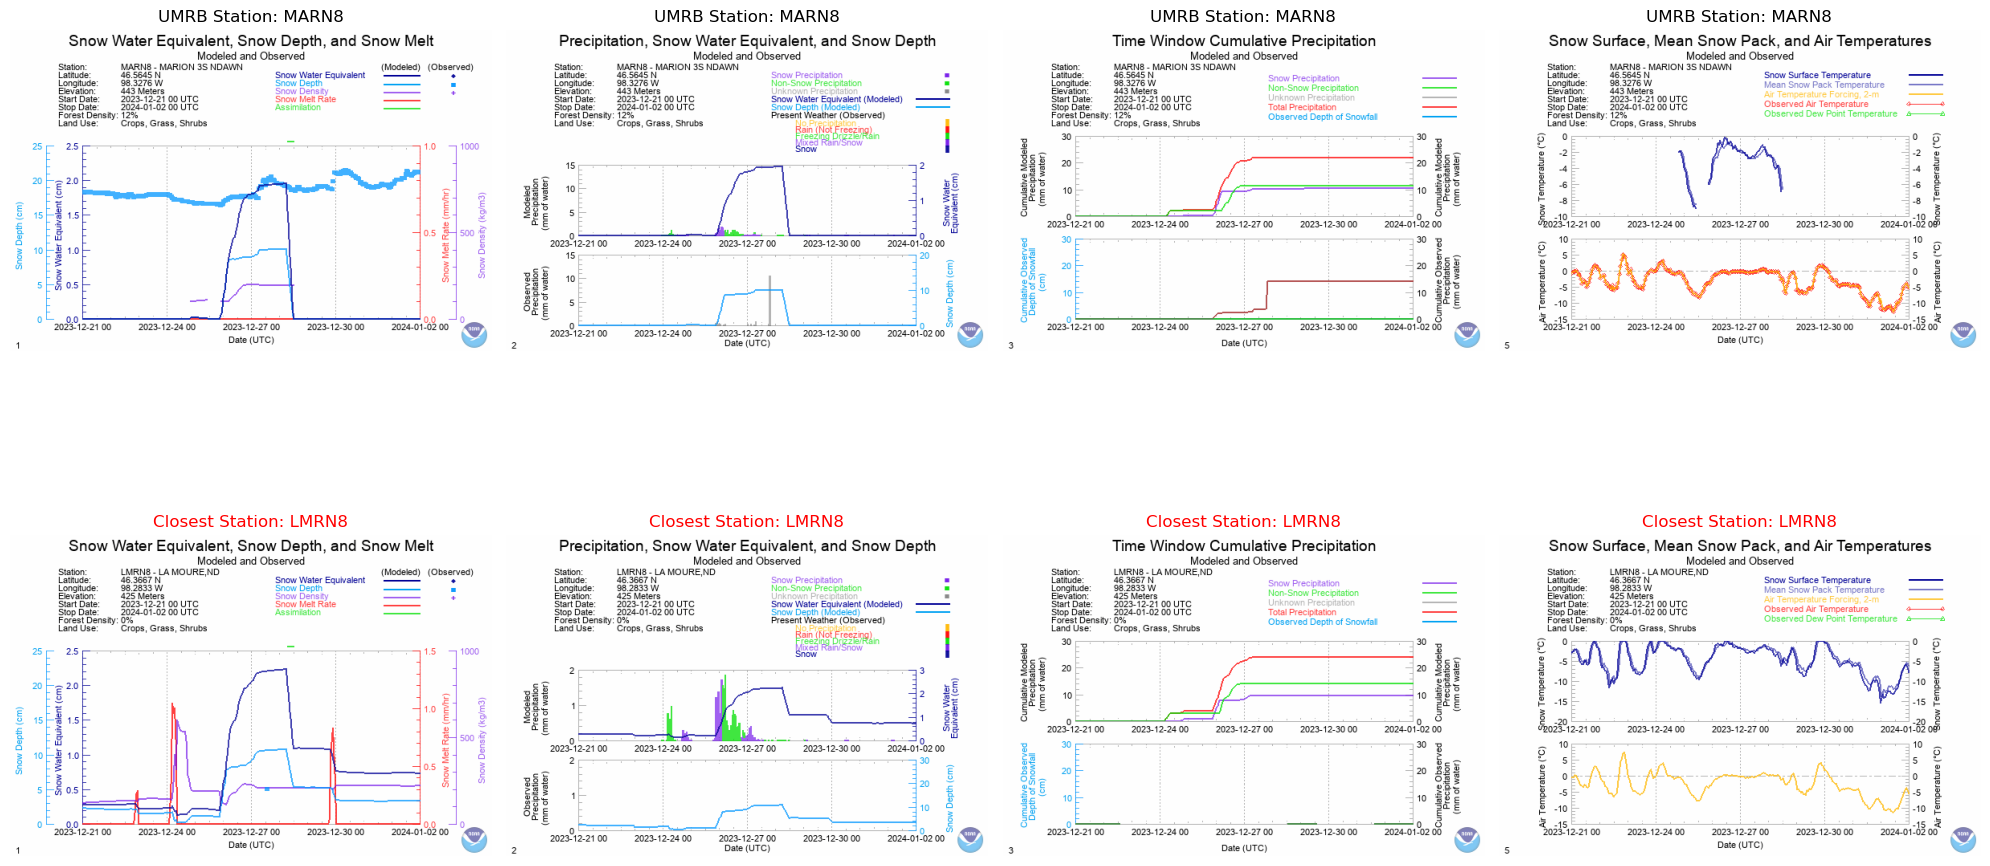

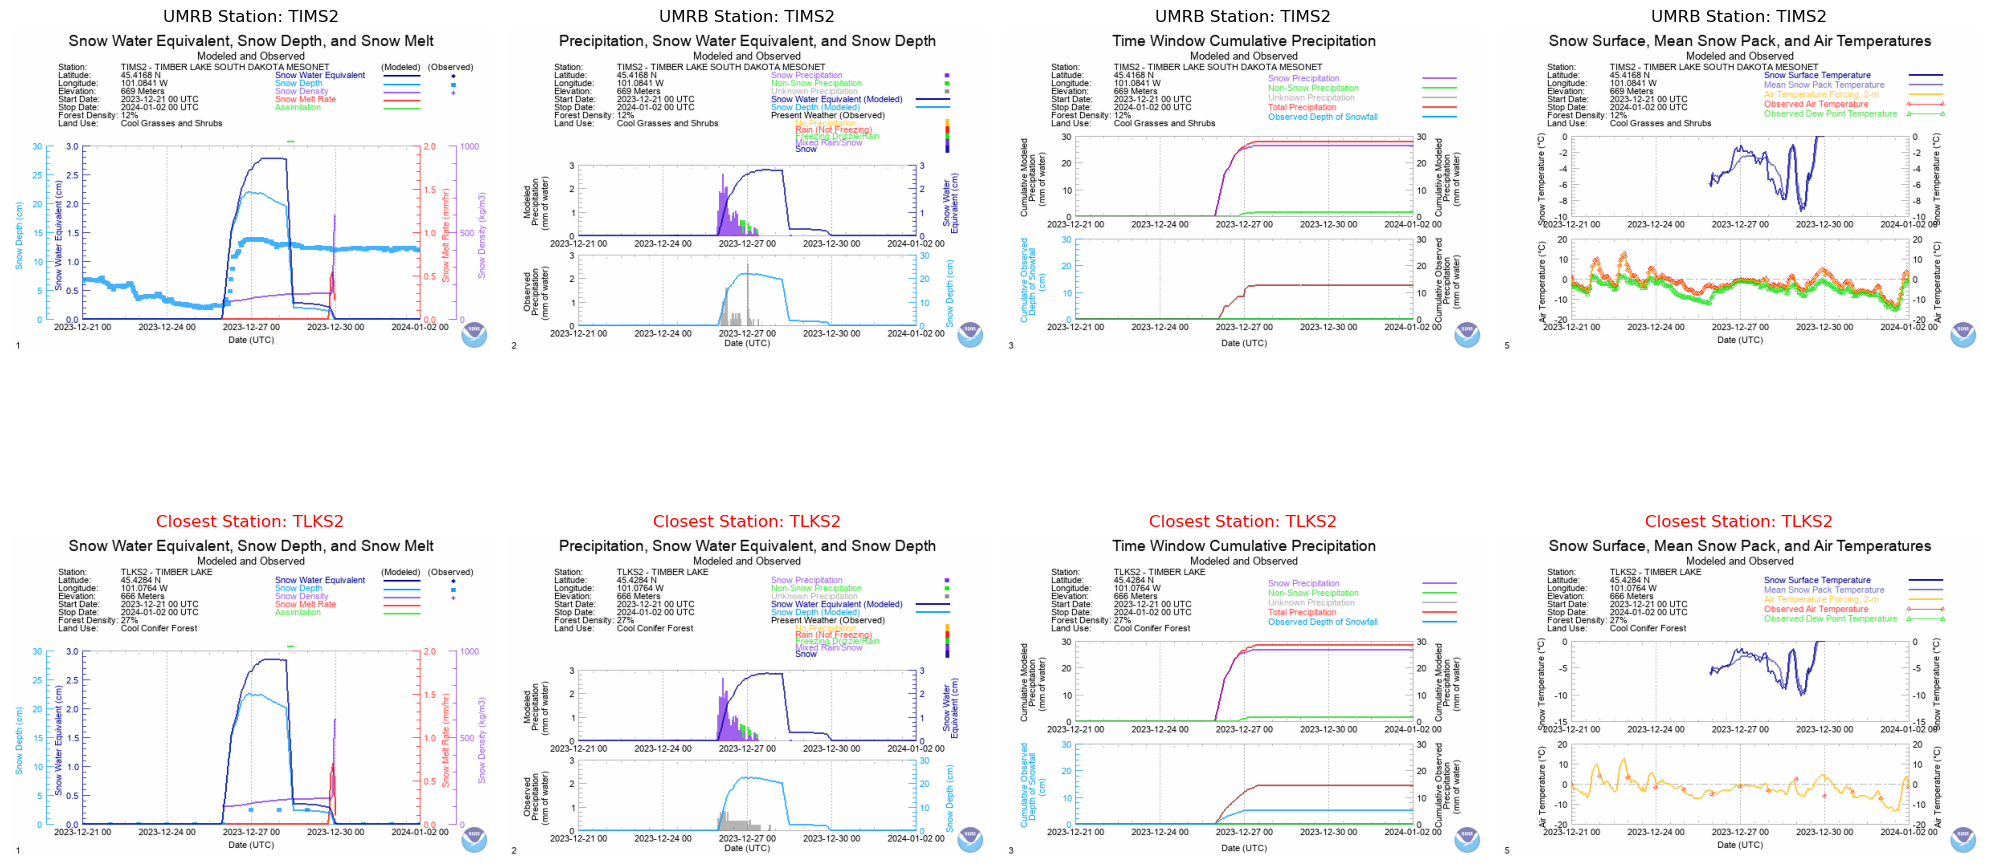

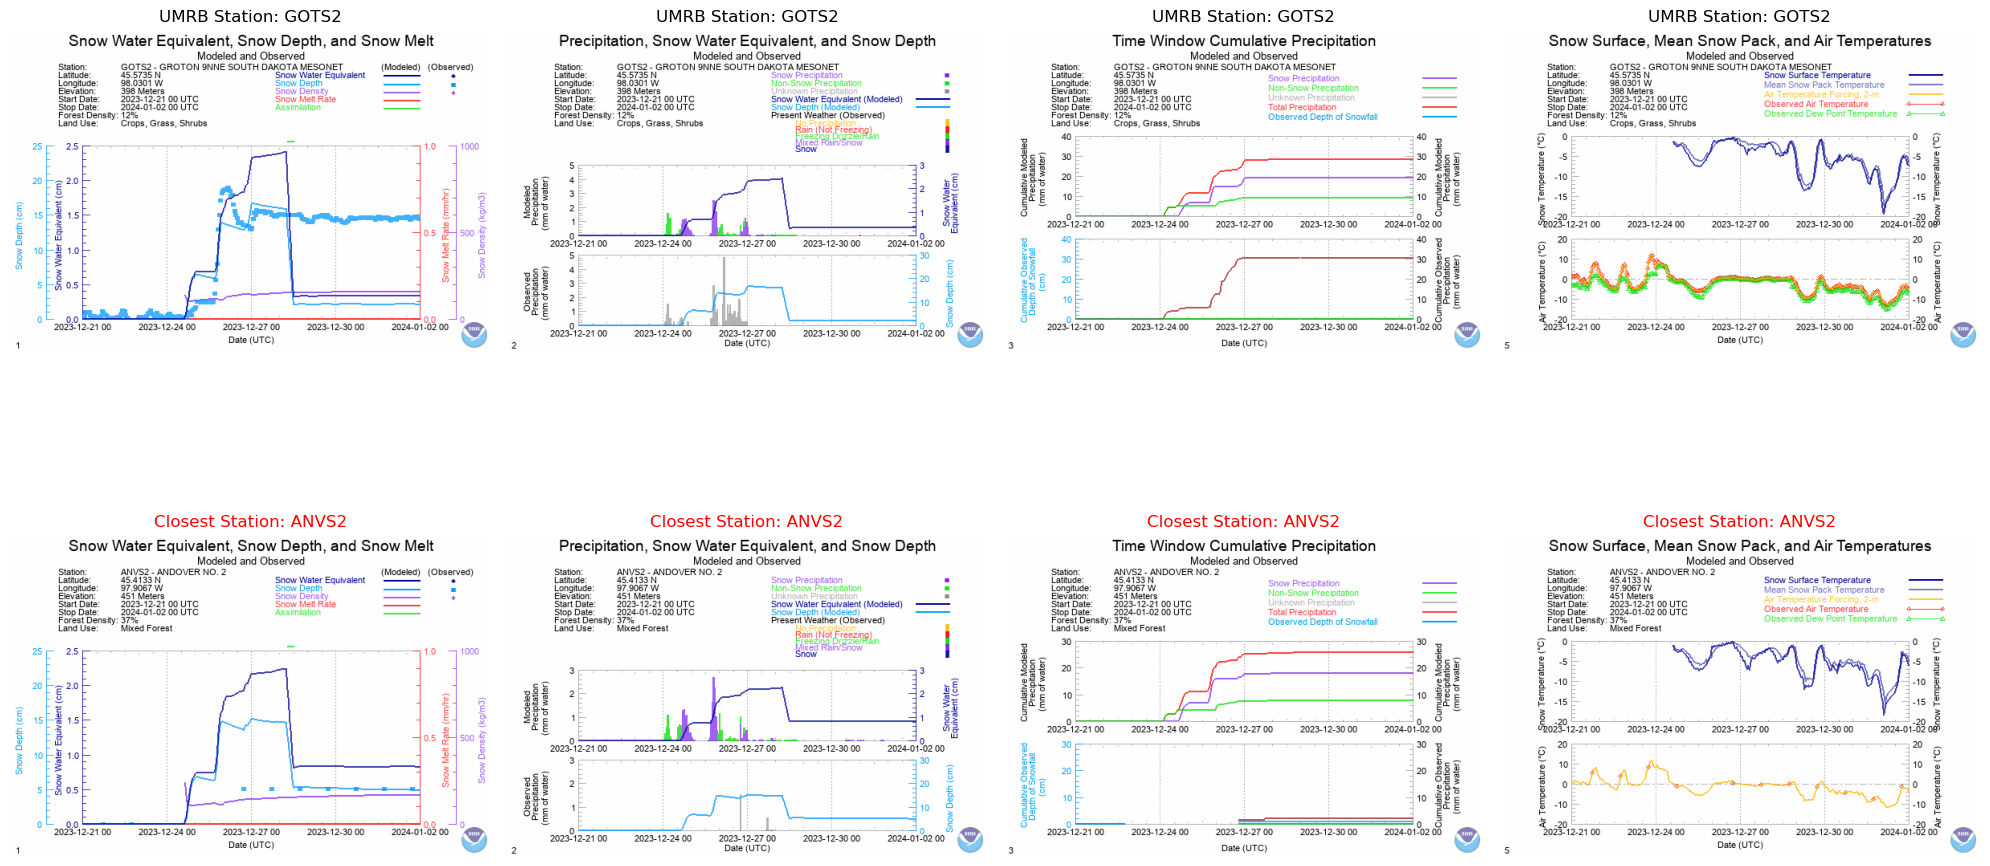

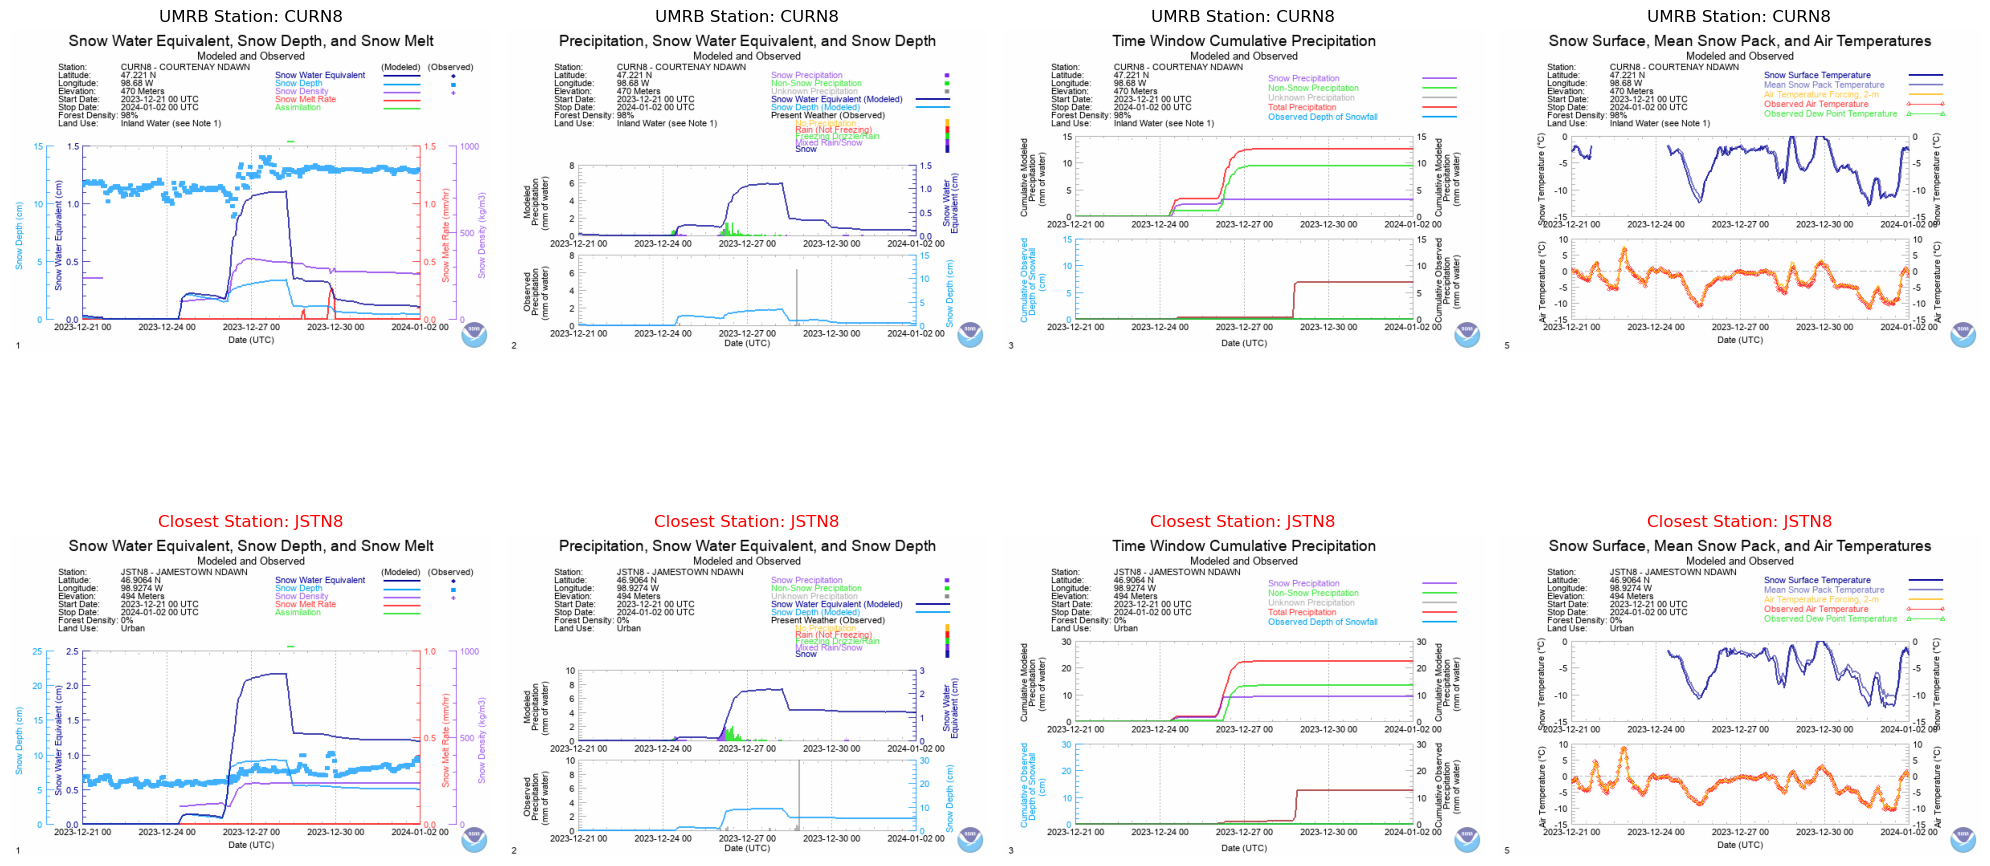

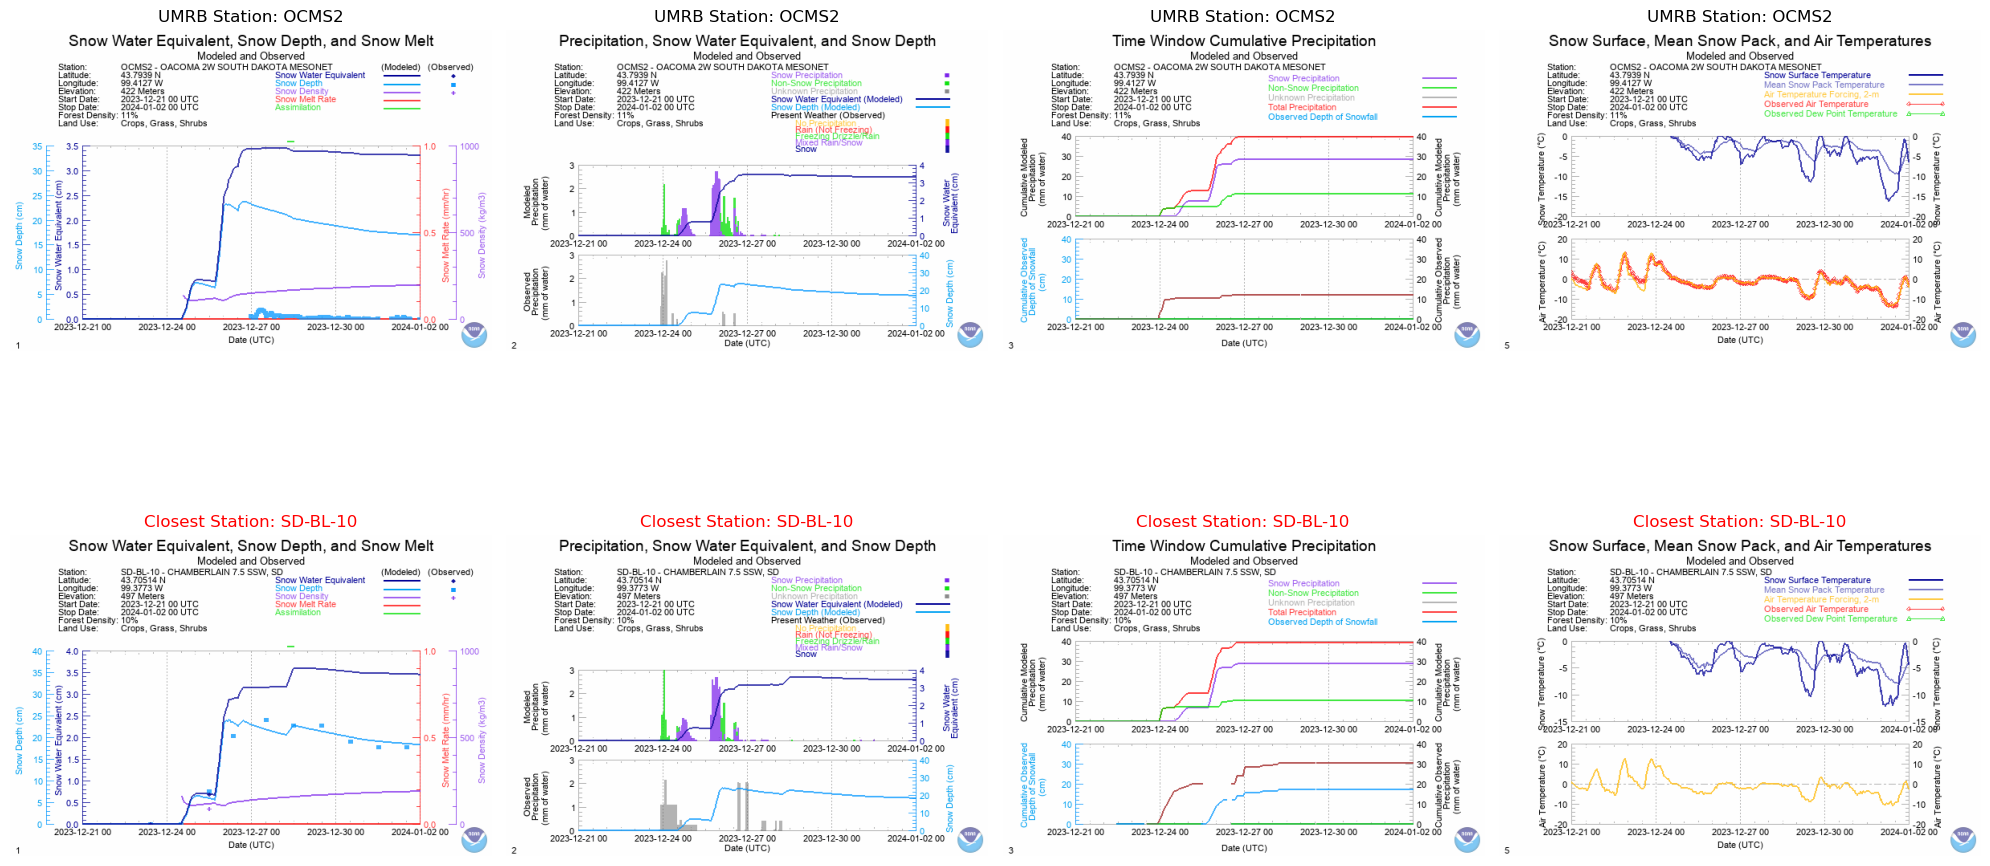

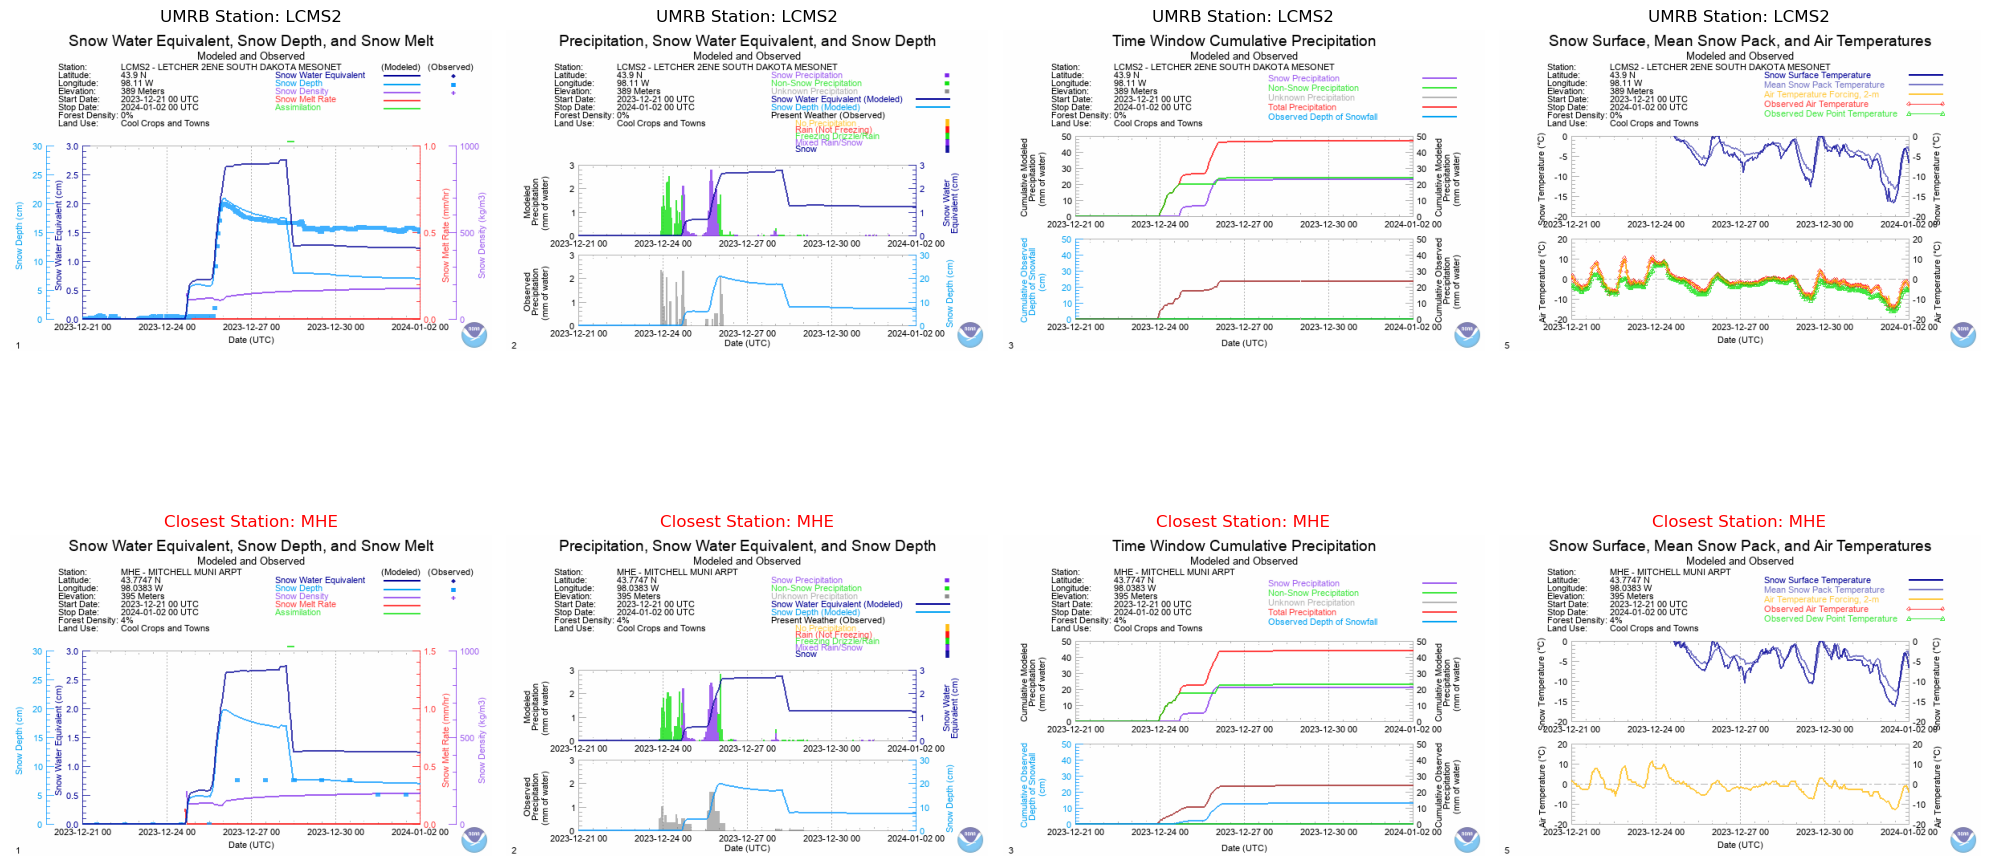

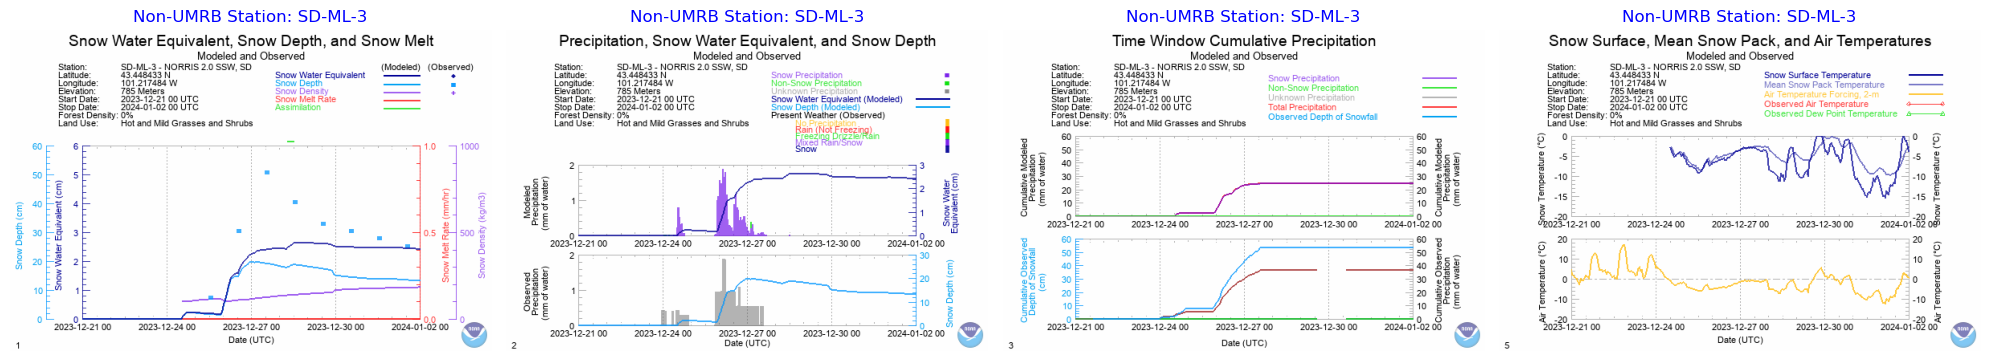

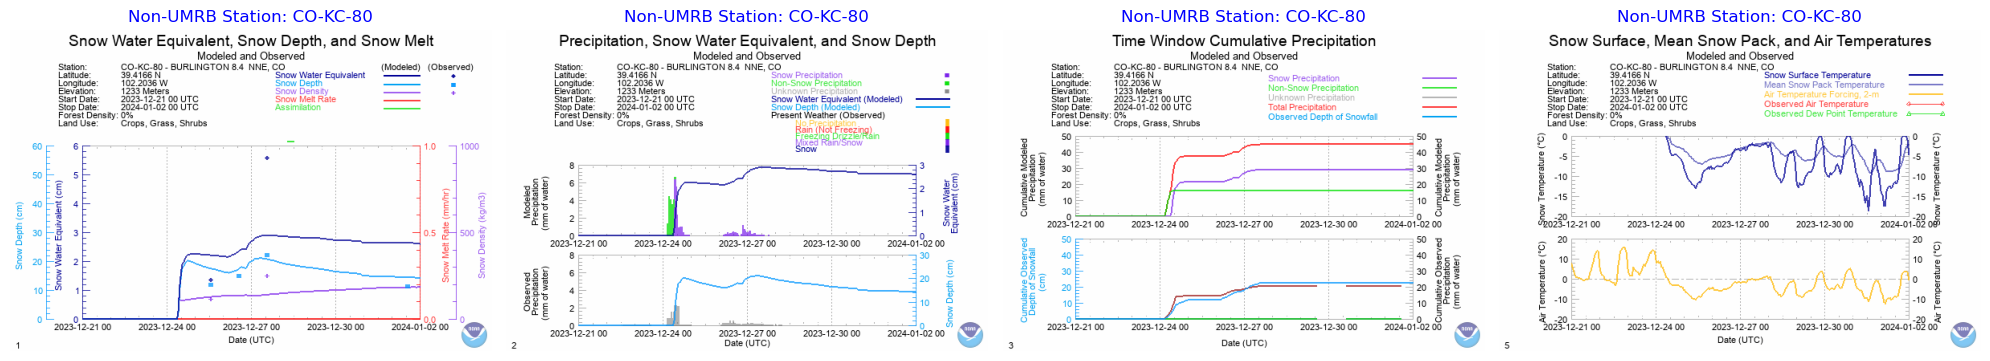

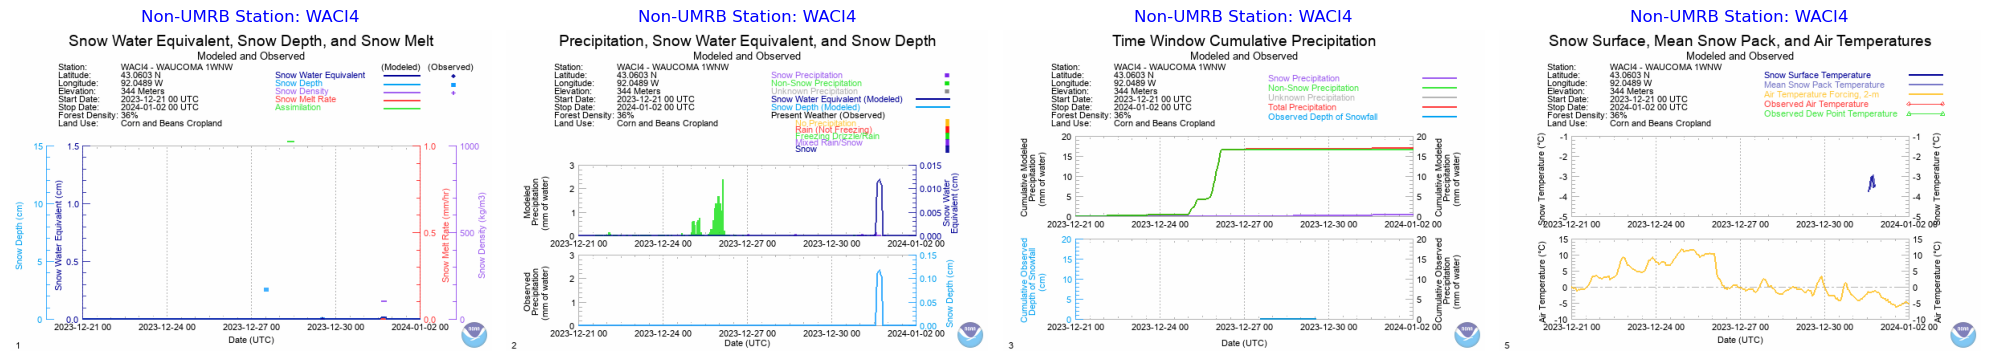

In [122]:
import requests
from PIL import Image
import io
import matplotlib.pyplot as plt

# Start and end date parameters
start_date = "by=2023&bm=12&bd=21&bh=00"
end_date = "ey=2024&em=01&ed=02&eh=00"

# Base URL for the images
base_url = "https://www.nohrsc.noaa.gov/interactive/html/graph_only.php?w=600&h=400"

# Function to download image from a URL
def download_image(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        return Image.open(io.BytesIO(response.content))
    except Exception as e:
        print(f"Error downloading image: {e}")
        return None

# Separate UMRB station IDs and closest station IDs
umrb_station_ids = top_10_abs_difference[top_10_abs_difference['STATION_TY'] == 'UMRB']['STATION_ID'].tolist()
closest_station_ids = closest_stations_df['Closest_Station_ID'].tolist()
non_umrb_station_ids = [station_id for station_id in station_ids if station_id not in umrb_station_ids and station_id not in closest_station_ids]

# Loop through UMRB stations and their closest stations
for umrb_station, closest_station in zip(umrb_station_ids, closest_station_ids):
    # Construct URLs for UMRB Station
    umrb_plot1_url = f"{base_url}&{start_date}&{end_date}&data=-1&region=us&units=1&station={umrb_station}"
    umrb_plot2_url = f"{base_url}&{start_date}&{end_date}&data=-2&region=us&units=1&station={umrb_station}"
    umrb_plot3_url = f"{base_url}&{start_date}&{end_date}&data=-3&region=us&units=1&station={umrb_station}"
    umrb_plot5_url = f"{base_url}&{start_date}&{end_date}&data=-5&region=us&units=1&station={umrb_station}"

    # Construct URLs for Closest Station
    closest_plot1_url = f"{base_url}&{start_date}&{end_date}&data=-1&region=us&units=1&station={closest_station}"
    closest_plot2_url = f"{base_url}&{start_date}&{end_date}&data=-2&region=us&units=1&station={closest_station}"
    closest_plot3_url = f"{base_url}&{start_date}&{end_date}&data=-3&region=us&units=1&station={closest_station}"
    closest_plot5_url = f"{base_url}&{start_date}&{end_date}&data=-5&region=us&units=1&station={closest_station}"

    # Download images for UMRB Station
    umrb_images = [download_image(url) for url in [umrb_plot1_url, umrb_plot2_url, umrb_plot3_url, umrb_plot5_url]]

    # Download images for Closest Station
    closest_images = [download_image(url) for url in [closest_plot1_url, closest_plot2_url, closest_plot3_url, closest_plot5_url]]

    # Check if all images were downloaded successfully
    if all(umrb_images) and all(closest_images):
        # Display the images using Matplotlib
        fig, axes = plt.subplots(2, 4, figsize=(20, 12))

        # Plot UMRB Station (Top Row)
        for i, img in enumerate(umrb_images):
            axes[0, i].imshow(img)
            axes[0, i].set_title(f"UMRB Station: {umrb_station}", color='black')
            axes[0, i].axis("off")

        # Plot Closest Station (Bottom Row, Red Title)
        for i, img in enumerate(closest_images):
            axes[1, i].imshow(img)
            axes[1, i].set_title(f"Closest Station: {closest_station}", color='red')
            axes[1, i].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping station pair ({umrb_station}, {closest_station}) due to download error.")

# Loop through remaining non-UMRB stations and plot them at the end
for station_id in non_umrb_station_ids:
    # Construct URLs for the station
    plot1_url = f"{base_url}&{start_date}&{end_date}&data=-1&region=us&units=1&station={station_id}"
    plot2_url = f"{base_url}&{start_date}&{end_date}&data=-2&region=us&units=1&station={station_id}"
    plot3_url = f"{base_url}&{start_date}&{end_date}&data=-3&region=us&units=1&station={station_id}"
    plot5_url = f"{base_url}&{start_date}&{end_date}&data=-5&region=us&units=1&station={station_id}"

    # Download images for the station
    images = [download_image(url) for url in [plot1_url, plot2_url, plot3_url, plot5_url]]

    # Check if all images were downloaded successfully
    if all(images):
        # Display the images using Matplotlib
        fig, axes = plt.subplots(1, 4, figsize=(20, 6))

        # Plot the non-UMRB station (Blue Title)
        for i, img in enumerate(images):
            axes[i].imshow(img)
            axes[i].set_title(f"Non-UMRB Station: {station_id}", color='blue')
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping station {station_id} due to download error.")


The function below grabs the actual data from each time series and creates a dataframe that is searchable for each station to view time series data for each time series plot (Select plot you want data from and station id example shown in cell #2 below)

In [124]:
import pandas as pd
import requests
import io

# Dictionaries to store the data for each station
plot1_data = {}
plot2_data = {}
plot3_data = {}
plot5_data = {}

# Function to download CSV data for a specific plot from a station within a date range
def download_plot_data(station_id, plot_number):
    # Construct the URL for the CSV file with date range
    url = (
        f"https://www.nohrsc.noaa.gov/interactive/html/graph.html?"
        f"w=600&h=400&data={plot_number}&region=us&units=1&station={station_id}"
        f"&by=2023&bm=12&bd=21&bh=00"  # Start date: 12/21/2023 0:00 Z
        f"&ey=2024&em=01&ed=02&eh=00"  # End date: 01/02/2024 0:00 Z
    )
    
    try:
        # Send a request to download the CSV data
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for unsuccessful requests
        
        # Read the CSV data into a DataFrame
        csv_data = pd.read_csv(io.StringIO(response.text), delimiter=',')
        
        # Convert the 'Date' column to datetime format
        if 'Date' in csv_data.columns:
            csv_data['Date'] = pd.to_datetime(csv_data['Date'], errors='coerce')
        
        # Filter the data for the specified date range
        start_date = pd.to_datetime("2023-12-21 00:00:00")
        end_date = pd.to_datetime("2024-01-02 00:00:00")
        filtered_data = csv_data[(csv_data['Date'] >= start_date) & (csv_data['Date'] <= end_date)]
        
        # Print the first few rows of the filtered DataFrame for verification
        print(f"\nData for Station {station_id}, Plot {plot_number} (Filtered):")
        print(filtered_data.head())
        
        return filtered_data
    
    except Exception as e:
        print(f"Error downloading data for station {station_id}, Plot {plot_number}: {e}")
        return None

# Loop through each station ID and download the data for Plot 1, Plot 2, Plot 3, and Plot 5
for station_id in station_ids:
    # Download data for each plot and store in respective dictionaries
    plot1 = download_plot_data(station_id, 11)  # Plot 1 Data
    plot2 = download_plot_data(station_id, 12)  # Plot 2 Data
    plot3 = download_plot_data(station_id, 13)  # Plot 3 Data
    plot5 = download_plot_data(station_id, 15)  # Plot 5 Data

    if plot1 is not None:
        plot1_data[station_id] = plot1
    if plot2 is not None:
        plot2_data[station_id] = plot2
    if plot3 is not None:
        plot3_data[station_id] = plot3
    if plot5 is not None:
        plot5_data[station_id] = plot5

# Display a summary of the collected data for each plot
print("\nSummary of downloaded data:")

for station_id in station_ids:
    if station_id in plot1_data:
        print(f"Station {station_id} - Plot 1: {len(plot1_data[station_id])} rows")
    if station_id in plot2_data:
        print(f"Station {station_id} - Plot 2: {len(plot2_data[station_id])} rows")
    if station_id in plot3_data:
        print(f"Station {station_id} - Plot 3: {len(plot3_data[station_id])} rows")
    if station_id in plot5_data:
        print(f"Station {station_id} - Plot 5: {len(plot5_data[station_id])} rows")




Data for Station MARN8, Plot 11 (Filtered):
                 Date  (Modeled) Snow Water Equivalent (cm)  \
0 2023-12-21 00:00:00                                   0.0   
1 2023-12-21 01:00:00                                   0.0   
2 2023-12-21 02:00:00                                   0.0   
3 2023-12-21 03:00:00                                   0.0   
4 2023-12-21 04:00:00                                   0.0   

   (Observed) Snow Water Equivalent (cm)  (Modeled) Snow Depth (cm)  \
0                                    NaN                        0.0   
1                                    NaN                        0.0   
2                                    NaN                        0.0   
3                                    NaN                        0.0   
4                                    NaN                        0.0   

   (Observed) Snow Depth (cm)  (Modeled) Snow Density (kg/m3)  \
0                       18.29                             NaN   
1                  

Like mentioned above just adjust what plot you want data from and also which gauge you want to view

In [125]:
df = plot2_data['LMRN8']

df

,Date,(Modeled) Snow Precipitation (mm of water),(Modeled) Non-Snow Precipitation (mm of water),(Observed) Snow Precipitation (mm of water),(Observed) Non-Snow Precipitation (mm of water),(Observed) Unknown Precipitation (mm of water),(Modeled) Snow Water Equivalent (cm),(Modeled) Snow Depth (cm),(Observed) Present Weather,Date w/o Time,Hour,Forecasted from 0 UTC
0,2023-12-21 00:00:00,0.0,0.0,NaN,NaN,0.0,0.28,2.29,NaN,2023-12-21,0,n
1,2023-12-21 01:00:00,0.0,0.0,NaN,NaN,0.0,0.28,2.29,NaN,2023-12-21,1,n
2,2023-12-21 02:00:00,0.0,0.0,NaN,NaN,0.0,0.28,2.28,NaN,2023-12-21,2,n
3,2023-12-21 03:00:00,0.0,0.0,NaN,NaN,0.0,0.28,2.27,NaN,2023-12-21,3,n
4,2023-12-21 04:00:00,0.0,0.0,NaN,NaN,0.0,0.28,2.26,NaN,2023-12-21,4,n
...,...,...,...,...,...,...,...,...,...,...,...,...
284,2024-01-01 20:00:00,0.0,0.0,NaN,NaN,0.0,0.73,3.34,NaN,2024-01-01,20,n
285,2024-01-01 21:00:00,0.0,0.0,NaN,NaN,0.0,0.73,3.33,NaN,2024-01-01,21,n
286,2024-01-01 22:00:00,0.0,0.0,NaN,NaN,0.0,0.73,3.31,NaN,2024-01-01,22,n
287,2024-01-01 23:00:00,0.0,0.0,NaN,NaN,0.0,0.73,3.31,NaN,2024-01-01,23,n


## Analysis of 12/28/23 time series data

### After looking at the 10 worst performing gauges we can see that almost all of these stations have modeled mixed precipitation. The complex nature of being able to model if the precip is falling as snow or rain can cause mixed results for nearby gauges causing large differences. You can also see in the comparison to nearby gauges that the SNODAS model is accurately predicitng snow depth at one location but inacurrate at the other nearby gauge. The UMRB gauges are not correlated with the closest nearby gauge, the observed depths are very different from one another. This highlights the importance of these gauges to accurately predict actual SWE at these locations and shows the potential improvement in the SNODAS model.

### One question I had is if these UMRB stations were used in the real assimilation because the modeled snow depth and SWE seems to adjust to the non-UMRB stations but not the UMRB stations. For example the LMCS2 station seems to match the modeled snow depth very well but the assimilation then adjusts it back down to the closest gauge snow depth which makes the modeled difference at LMCS2 a lot worse now.